# Figure: Farmer Prices

This notebook generates figures from **Experiment 4** results.

**Inputs**: `../data/results_4/` (JSON files), `../data/instances/2020-08-27.yaml`

**Outputs**:
- `../figures/boxplots_prices.pdf` — Price distributions by intermediary deviation potential and road type
- `../figures/farmer_payments.pdf` — Scatter plot of farmer payments vs. harvested quantity

In [6]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from copy import deepcopy

from farmers_intermediaries import Instance
from road_graphs import RoadGraph
import pickle
import pandas as pd
import pricing
from pricing import Optimizer
from datetime import datetime, timedelta
import numpy as np


json_files = {}
directory = "../data/results_exp_4_new"

for filename in os.listdir(directory):
    if filename.endswith(".json"):
        filepath = os.path.join(directory, filename)
        with open(filepath, 'r') as file:
            json_files[filename] = json.load(file)

In [18]:
summ_dict = []
farmer_dict = []
maximum = -np.inf
minimum = np.inf
for name, json_file in json_files.items():
    for grid_index, result in enumerate(json_file):
        avg_payments = sum(result["summary_vanilla"]["max_int_welf_sol"]["farmer_prices"][farmer_id]/result["farmer_quantities"][farmer_id] for farmer_id in result["farmer_quantities"]) / len(result["farmer_quantities"])
        for farmer_id in result["farmer_quantities"]:
            int_id = farmer_id.split('_')[0] + '_' + farmer_id.split('_')[1]
            summ_dict.append({
                "epsilon": result["epsilon"],
                "quantity": result["farmer_quantities"][farmer_id],
                "instance_id": result["instance_id"],
                "payment_min": result["summary_vanilla"]["max_int_welf_sol"]["farmer_prices"][farmer_id],
                "payment_max": result["summary_vanilla"]["min_int_welf_sol"]["farmer_prices"][farmer_id],
                "farmer_id": farmer_id,
                "dirt_to_mill": result["farmer_dirt_to_mill"][farmer_id],
                "paved_to_mill": result["farmer_paved_to_mill"][farmer_id],
                "int_power":result["summary_vanilla"]["instance"]["status_quo_quantities"][int_id]+result["epsilon"][int_id],
                "int_matched": result["summary_vanilla"]["max_int_welf_sol"]['intermediary_profits'][int_id]>10,
                "payment_per_kg": result["summary_vanilla"]["max_int_welf_sol"]["farmer_prices"][farmer_id] / result["farmer_quantities"][farmer_id]/14500.0,
            })

df = pd.DataFrame(summ_dict)
#df = df.query("power >= 2.0 and power <=8.5")
df['dirt_to_mill'] = df['dirt_to_mill']/(2625)/4
df['paved_to_mill'] = df['paved_to_mill']/(2625)

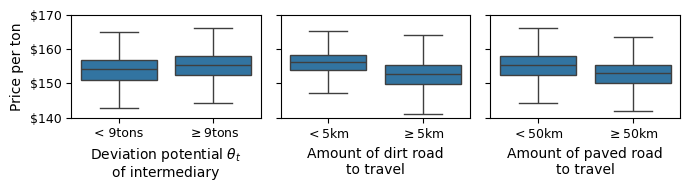

In [19]:
import seaborn as sns

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

# Update global plot parameters
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Function to format y-axis as dollars
def dollar_formatter(x, pos):
    return f'${int(x)}'

formatter = FuncFormatter(dollar_formatter)

# Change bin labels to Low and High
df['int_power_bin'] = pd.cut(
    df['int_power'],
    bins=[-float('inf'), 9, float('inf')],
    labels=['< 9tons', r'$\geq 9$tons']
)

df['dirt_to_mill_bin'] = pd.cut(
    df['dirt_to_mill'],
    bins=[-float('inf'), 5, float('inf')],
    labels=[r'$< 5$km', r'$\geq 5$km']
)

df['paved_to_mill_bin'] = pd.cut(
    df['paved_to_mill'],
    bins=[-float('inf'), 50, float('inf')],
    labels=[r'$< 50$km', r'$\geq 50$km']
)

# Create a single figure with 3 subplots horizontally
fig, axes = plt.subplots(1, 3, figsize=(7, 2), sharey=True)

# First plot: Power to Deviate
sns.boxplot(
    data=df,
    x='int_power_bin',
    y='payment_per_kg',
    showfliers=False,
    ax=axes[0]
)

axes[0].set_xlabel(r'Deviation potential $\theta_t$'+'\nof intermediary')
axes[0].set_ylabel('Price per ton')
axes[0].set_ylim(130, 170)
axes[0].yaxis.set_major_formatter(formatter)

# Second plot: Dirt road
sns.boxplot(
    data=df,
    x='dirt_to_mill_bin',
    y='payment_per_kg',
    showfliers=False,
    ax=axes[1]
)
axes[1].set_xlabel('Amount of dirt road\nto travel')
axes[1].set_ylabel('')
axes[1].set_ylim(130, 170)
axes[1].yaxis.set_major_formatter(formatter)

# Third plot: Paved road
sns.boxplot(
    data=df,
    x='paved_to_mill_bin',
    y='payment_per_kg',
    showfliers=False,
    ax=axes[2]
)
axes[2].set_xlabel('Amount of paved road\nto travel')
axes[2].set_ylabel('')
axes[2].set_ylim(140, 170)
axes[2].yaxis.set_major_formatter(formatter)

# No shared title this time
plt.tight_layout()
plt.savefig("../figures/boxplots_prices.pdf", bbox_inches='tight')

plt.show()


/var/folders/7_/y4vpj6ln7b90djzq_hscbgyr0000gn/T/ipykernel_39965/2127024706.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


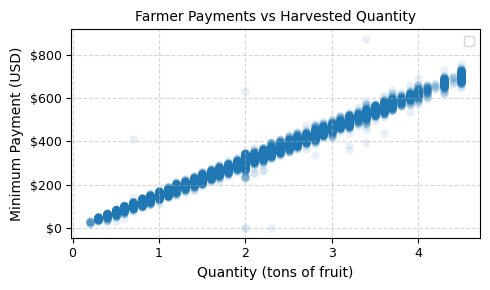

In [20]:
import matplotlib.pyplot as plt

# Update global plot parameters
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

plt.figure(figsize=(5, 3))

# Scatter plot with improved visibility
plt.scatter(
    df['quantity'], df['payment_min']/14500.0,
    alpha=0.1,
    edgecolors='k',
    linewidths=0,
)

# Axis labels and title
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xlabel('Quantity (tons of fruit)')
plt.ylabel('Minimum Payment (USD)')
plt.title('Farmer Payments vs Harvested Quantity')

# Add legend and grid
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: improve spacing
plt.tight_layout()
plt.savefig("../figures/farmer_payments.pdf", bbox_inches='tight')  # INFORMS-compliant

plt.show()